# Plausible-value check: `tas`, `tasmax`, `tasmin`, `pr`

This notebook checks whether the downscaled temperature and precipitation outputs stay inside a *location- and
season-aware* plausible range. The global sanity bounds used elsewhere (the "reasonable ranges"
Check 3 in the [output-integrity notebook](tas-tasmax-tasmin-integrity-checks.ipynb))
catch gross errors such as a mean temperature of 500 K, but they say nothing about values that are
globally ordinary yet locally impossible. A daily maximum of 25 °C is unremarkable in most of the
world, but in Antarctica in winter it should raise eyebrows.

To catch that second class of problem we build, for every grid cell and every day of the year, a
plausible envelope from the coarse GCM's modeled day-of-year variability (scenario relative to
historical) added to the observed ERA5 day-of-year envelope. We then ask, per leaf, what fraction of
the domain ever leaves that envelope, and by how much. The check is deliberately wide: it is meant to
flag suspect cells for inspection, not to fail a leaf on a single warm afternoon.

For precipitation the envelope is built the same additive way, but only its upper bound carries
information. Precipitation cannot go below zero, so the lower bound — the observed day-of-year
minimum plus the modeled change — is generally negative and never flags a cell; the precipitation
check therefore measures how far the downscaled output rises above the wettest observed day plus the
coarse model's modeled increase. Exceedance magnitudes and map color scales are reported in each
variable's native units — kelvin for `tas`/`tasmax`/`tasmin`, kg m⁻² s⁻¹ for `pr` — rather than
assuming kelvin throughout.

The notebook follows the structure of the output-integrity notebook: open the output store once,
discover the `(scenario, variable, member)` leaves programmatically, express every reduction lazily,
and materialize them one `dask.compute` per variable. That batching keeps the leaves of each variable
running in parallel instead of one-at-a-time, which is the change that lets it scale past a
single-region test.

In [1]:
import functools
import os
import pathlib
import time

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import coiled
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register

from srm import catalog
from srm.config import ClusterConfig, _icechunk_storage_for_path
from srm.lineage import resolve_member_lineage
from srm.qaqc import obs_doy_bounds, scenario_delta_doy

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# v0.11.1 is the latest production run; it carries the tas/tasmax/tasmin triplet and precipitation (pr).
GCM = "CESM2-WACCM"
STORE_URI = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.11.1"
VARIABLES = ["tas", "tasmax", "tasmin", "pr"]
SPATIAL = ["lat", "lon"]

# Bounds construction: obs baseline start year and day-of-year rolling window
# (window matches the srm.qaqc default).
OBS_START_YEAR = 1978
WINDOW = 30

# A leaf is flagged when more than this fraction of the domain leaves the envelope.
FLAG_THRESHOLD = 0.02

# Per-leaf CSV + PNG artifacts (kept from the original notebook for downstream use).
QAQC_DIR = "/scratch/synced/qa_plots/plausible_value_check/"

# Optional fast path for a quick regional test run: set to (lat_slice, lon_slice)
# in the store's coordinate convention, or None to check the whole globe.
SUBSET = None
# SUBSET = (slice(-35, -22), slice(16, 33))  # the original Namibia test box


def apply_subset(da: xr.DataArray) -> xr.DataArray:
    """Restrict to SUBSET for a fast regional run; identity when SUBSET is None."""
    if SUBSET is None:
        return da
    lat_slice, lon_slice = SUBSET
    return da.sel(lat=lat_slice, lon=lon_slice)

## Compute

The output store lives in S3 in `us-west-2` and the check reads every cell of the fine-grid
temperature and precipitation arrays, so we run on a distributed [Coiled](https://coiled.io) cluster in the same
region. The settings below mirror `srm.config.ClusterConfig`, the same configuration the pipeline
itself uses, but pin a *fixed*, *on-demand* worker pool rather than an adaptive spot one: this check
is a single long `groupby`-reduce, and a worker that disappears mid-run — through spot reclamation or
an adaptive downscale — discards reduction partials that `frisky` cannot recompute. We wrap the
client with `frisky` so progress stays visible while the reductions run.

In [2]:
# Global run reads ~2 TB across the fine-grid leaves. Prefer fewer, larger worker processes
# with more threads each (coiled runs one process per VM, threads = vCPUs): the reductions are
# GIL-releasing zarr/flox/numpy and the large day-of-year intermediates are shared within a
# process. r8g.4xlarge = 16 threads / 128 GB per worker; add worker_options={"nthreads": 8}
# to coiled.Cluster if peak memory runs hot.
#
# Use a FIXED, on-demand pool, not adaptive spot. This check is one long groupby-reduce over the
# full record, so a worker that disappears mid-run discards the groupby-cohort partials the
# reduction depends on — which frisky surfaces as an unrecoverable "missing dependencies"
# invariant violation rather than recomputing. A fixed worker count removes adaptive downscaling
# and on-demand removes spot reclamation, the two ways a worker vanishes.
cfg = ClusterConfig(
    n_workers=30,
    worker_vm_types=["r8g.8xlarge"],
    scheduler_vm_types=["r8g.xlarge"],
    spot_policy="on-demand",
)
cluster = coiled.Cluster(
    name="srm-qaqc-plausible-check",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=250,
)
client = hijack(cluster.get_client())
client

## The output store and leaf discovery

A single icechunk store holds every result, versioned by branch. The plausible-value check runs on
the fine-grid downscaled outputs in the top-level scenario groups (`historical`, `ssp245`,
`g6_1p5k`); the coarse `debiased_coarse/…` subtree is only used later, in the single-point
drill-down. We open the store once as a datatree and discover the `(scenario, variable, member)`
leaves by walking its children, so there is no hand-maintained list of runs to keep in sync with the
store.

In [3]:
repo = icechunk.Repository.open(_icechunk_storage_for_path(STORE_URI))
session = repo.readonly_session(BRANCH)

tree = xr.open_datatree(session.store, engine="zarr", chunks={})
tree

,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"


In [4]:
# Store groups and lineage labels differ: the store (and the raw GCM catalog) key scenarios as
# lowercase group names, while srm.lineage keys them by label. This map bridges the two.
SCENARIO_LABELS = {"historical": "historical", "ssp245": "SSP245", "g6_1p5k": "G6-1.5K"}


def group_leaves(group: str) -> dict[tuple[str, str, str], xr.DataArray]:
    """One lazy fine-grid DataArray per (group, variable, member) present under tree[group]."""
    node = tree[group]
    return {
        (group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in VARIABLES
        if v in node.children
        for m in node[v].children
    }


leaves: dict[tuple[str, str, str], xr.DataArray] = {}
for group in SCENARIO_LABELS:
    leaves.update(group_leaves(group))


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (scenario, variable, member)."""
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(
        ["scenario", "variable", "member"]
    )


print(f"{len(leaves)} (scenario, variable, member) leaves discovered:")
for key in leaves:
    print("  " + "/".join(key))

14 (scenario, variable, member) leaves discovered:
  historical/tas/r3i1p1f1
  historical/tasmax/001
  historical/tasmin/001
  historical/pr/r3i1p1f1
  ssp245/tas/003
  ssp245/tas/008
  ssp245/tasmax/008
  ssp245/tasmin/008
  ssp245/pr/003
  ssp245/pr/008
  g6_1p5k/tas/003
  g6_1p5k/tasmax/003
  g6_1p5k/tasmin/003
  g6_1p5k/pr/003


## Part 1 — the plausible-range check

For each leaf we build a per-day-of-year plausible envelope and measure how far the downscaled output
strays from it. The envelope has two ingredients that live on different grids and cost very different
amounts to compute. The observed piece, `obs_doy_bounds`, is the ERA5 day-of-year min/max envelope on
the fine grid; it is the expensive part, but it depends only on the variable, so we compute it once
per variable and share it across every scenario and member. The scenario piece, `scenario_delta_doy`,
is the coarse GCM's day-of-year change relative to the historical mean; it is cheap and genuinely
per-leaf, and we regrid it onto the observation grid (nearest neighbor) before adding it to the
observed envelope.

The historical baseline member for each leaf comes from `srm.lineage` rather than a hand-written
table — for the SAI and SSP245 scenarios `tas` and the extrema are drawn from different historical
runs, exactly the split the integrity notebook documents. Each leaf's reductions are defined lazily
in `plausibility_stats`, and because every leaf of a given variable references the *same* lazy
`obs_doy_bounds` object, that variable's `dask.compute` evaluates the shared observed envelope only
once.

In [5]:
CESM = catalog.get("CESM2-WACCM").to_xarray()  # DataTree keyed by scenario group
ERA5 = catalog.get("ERA5").to_xarray()


def obs_fine(var: str) -> xr.DataArray:
    """Fine-grid ERA5 observations for a variable, from OBS_START_YEAR onward."""
    da = ERA5[var]
    da = da.sel(time=slice(str(OBS_START_YEAR), None))
    return apply_subset(da)


@functools.cache
def obs_bounds_cached(var: str) -> tuple[xr.DataArray, xr.DataArray]:
    """(low, high) observed day-of-year envelope, built once per variable and returned as a
    shared lazy object so every leaf of that variable reuses it and dask computes it once within
    the single dask.compute below. Do NOT persist this under frisky: frisky's persist gathers the
    result to the client (not the cluster) and the ~3 GB envelope overflows its ws proxy buffer;
    left lazy, the envelope stays a reduced intermediate that is never gathered."""
    return obs_doy_bounds(obs_fine(var), window=WINDOW)


def historical_member(scenario: str, var: str, member: str) -> str:
    """Historical baseline member for a leaf. The historical group has no scenario lineage, so its
    baseline is the leaf's own member; scenarios resolve through srm.lineage (raises KeyError if the
    combination is not registered)."""
    if scenario == "historical":
        return member
    return resolve_member_lineage(GCM, SCENARIO_LABELS[scenario], member, var)[0]


def plausibility_stats(scenario: str, var: str, member: str) -> xr.Dataset:
    """Lazy per-leaf plausibility reductions, fused into one pass over the array on compute."""
    downscaled = apply_subset(leaves[(scenario, var, member)])

    low_obs, high_obs = obs_bounds_cached(var)  # shared lazy per variable
    hist_member = historical_member(scenario, var, member)
    raw_scenario = apply_subset(CESM[scenario][var].sel(ensemble_member=member))
    raw_historical = apply_subset(CESM["historical"][var].sel(ensemble_member=hist_member))
    delta_low, delta_high = scenario_delta_doy(raw_scenario, raw_historical, window=WINDOW)

    # Nearest-neighbor coarse -> fine regrid via reindex, not interp: identical values for nearest
    # selection, but reindex is pure indexing and stays on one dask backend. interp routes through
    # apply_ufunc and mixes classic dask arrays with the query-planning (dask_array) backend that
    # Coiled uses, raising "Mixing chunked array types".
    regrid = {"lat": low_obs["lat"], "lon": low_obs["lon"], "method": "nearest"}
    high_bound = high_obs + delta_high.reindex(**regrid)
    low_bound = low_obs + delta_low.reindex(**regrid)

    doy_max = downscaled.groupby("time.dayofyear").max("time")
    doy_min = downscaled.groupby("time.dayofyear").min("time")
    over = (doy_max - high_bound).max(
        "dayofyear"
    )  # native units above the high bound (per cell, 2-D)
    under = (doy_min - low_bound).min(
        "dayofyear"
    )  # native units below the low bound (per cell, 2-D)

    return xr.Dataset(
        {
            "over": over,
            "under": under,
            "frac_area_too_high": (over > 0).mean(SPATIAL),
            "frac_area_too_low": (under < 0).mean(SPATIAL),
            "max_value": over.max(),
            "min_value": under.min(),
        }
    )


# Resolve historical baselines up front; skip (rather than fabricate) any leaf whose lineage is not
# registered, so a lineage gap surfaces instead of silently using the wrong historical member.
checkable, skipped = {}, []
for key in leaves:
    try:
        historical_member(*key)
        checkable[key] = leaves[key]
    except KeyError:
        skipped.append(key)
if skipped:
    print("Skipped (no registered lineage):")
    for key in skipped:
        print("  " + "/".join(key))

### Running the check

We materialize the reductions one variable at a time — a `dask.compute` per variable — so each batch
shares that variable's observed envelope (computing it once) while bounding peak cluster memory and
graph size to a single variable, and a failed batch costs one variable rather than the whole run. The
scalar metrics from every leaf collapse into one summary table: the fraction of the domain that is
ever too high or too low, the largest exceedance in each direction (in the variable's native units), and a pass flag using
the same 2 % threshold the original notebook used.

In [6]:
%%time

# Batch the compute by variable instead of one graph spanning every leaf. Every leaf of a variable
# shares the same lazy obs envelope (obs_bounds_cached), so one dask.compute per variable still
# evaluates that expensive envelope exactly once, while bounding peak cluster memory and graph size
# to a single variable at a time. The per-leaf results are tiny (scalars + 2-D maps), so accumulating
# them across batches is free.


def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


# Compute each variable independently: a transient failure retries, and a variable that still fails is
# recorded and skipped so the summary and maps still build on whatever did compute. This is what makes
# a failed batch cost one variable rather than the whole run — the fixed on-demand pool avoids losing
# reduction partials, and the retry recovers the transient blips it cannot design away.
stats = {}
failed_vars = []
for var in VARIABLES:
    batch_keys = [key for key in checkable if key[1] == var]
    if not batch_keys:
        continue
    batch = {key: plausibility_stats(*key) for key in batch_keys}
    try:
        stats.update(compute_with_retry(batch, label=f"[{var}] ")[0])
    except Exception as exc:
        failed_vars.append(var)
        print(f"  {var}: FAILED after retries ({type(exc).__name__}); continuing with the rest")
        continue
    print(f"  computed {var}: {len(batch_keys)} leaf(s)")

if failed_vars:
    print(
        f"\n!! variables that did not compute: {failed_vars} -- rerun those before trusting results"
    )

summary = table(
    {
        key: {
            "frac_area_too_high": round(float(s.frac_area_too_high), 5),
            "frac_area_too_low": round(float(s.frac_area_too_low), 5),
            "max_value": round(float(s.max_value), 3),
            "min_value": round(float(s.min_value), 3),
        }
        for key, s in stats.items()
    }
)
summary["pass"] = (summary.frac_area_too_high < FLAG_THRESHOLD) & (
    summary.frac_area_too_low < FLAG_THRESHOLD
)
print(summary.to_string())
print(
    f"\nAll leaves within plausible range (< {FLAG_THRESHOLD:.0%} of area flagged): "
    f"{bool(summary['pass'].all())}"
)

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tas: 4 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tasmax: 3 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tasmin: 3 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed pr: 4 leaf(s)
                              frac_area_too_high  frac_area_too_low  max_value  min_value   pass
scenario   variable member                                                                      
historical tas      r3i1p1f1             0.00025            0.00002      3.585     -0.354   True
ssp245     tas      003                  0.00331            0.00334      9.421    -11.952   True
                    008                  0.00241            0.00159      9.839     -8.769   True
g6_1p5k    tas      003                  0.00010            0.00000      3.267      0.113   True
historical tasmax   001                  0.00052            0.00003      3.341     -0.892   True
ssp245     tasmax   008                  0.00440            0.00297     13.072    -15.289   True
g6_1p5k    tasmax   003                  0.00160            0.00211      9.683    -13.380   True
historical tasmin   001                  0.00602            0.00200      6.105     -5.094   True
ssp24

### Per-leaf artifacts

We keep the original notebook's on-disk outputs for downstream use: a long-form CSV per leaf, a
combined CSV across all leaves, and the exceedance maps below. These are derived from the results
already in memory, so writing them triggers no recomputation.

In [7]:
pathlib.Path(QAQC_DIR).mkdir(parents=True, exist_ok=True)

METRICS = ["frac_area_too_high", "frac_area_too_low", "max_value", "min_value"]
records = [
    {
        "variable": var,
        "scenario": scenario,
        "ensemble_member": member,
        "metric": metric,
        "value": row[metric],
    }
    for (scenario, var, member), row in summary.iterrows()
    for metric in METRICS
]
combined = pd.DataFrame.from_records(records)

for (scenario, var, member), grp in combined.groupby(["scenario", "variable", "ensemble_member"]):
    grp.to_csv(f"{QAQC_DIR}area_out_of_range_frac_{var}_{scenario}_{member}.csv", index=False)
combined.to_csv(f"{QAQC_DIR}all_sims_local_range_checks.csv", index=False)
combined["flag_less_than_0pt02"] = combined["value"] < FLAG_THRESHOLD

combined.pivot_table(
    index=["scenario", "variable", "ensemble_member"], columns="metric", values="value"
)

metric                               frac_area_too_high  frac_area_too_low  \
scenario   variable ensemble_member                                          
g6_1p5k    pr       003                         0.00227            0.00000   
           tas      003                         0.00010            0.00000   
           tasmax   003                         0.00160            0.00211   
           tasmin   003                         0.00498            0.04501   
historical pr       r3i1p1f1                    0.01396            0.00000   
           tas      r3i1p1f1                    0.00025            0.00002   
           tasmax   001                         0.00052            0.00003   
           tasmin   001                         0.00602            0.00200   
ssp245     pr       003                         0.01574            0.00002   
                    008                         0.01471            0.00002   
           tas      003                         0.00331            0.00334   
                    008                         0.00241            0.00159   
           tasmax   008                         0.00440            0.00297   
           tasmin   008                         0.00703            0.03983   

metric                               max_value  min_value  
scenario   variable ensemble_member                        
g6_1p5k    pr       003                  0.004      0.000  
           tas      003                  3.267      0.113  
           tasmax   003                  9.683    -13.380  
           tasmin   003                  9.719    -20.585  
historical pr       r3i1p1f1             0.010      0.000  
           tas      r3i1p1f1             3.585     -0.354  
           tasmax   001                  3.341     -0.892  
           tasmin   001                  6.105     -5.094  
ssp245     pr       003                  0.008      0.000  
                    008                  0.008      0.000  
           tas      003                  9.421    -11.952  
                    008                  9.839     -8.769  
           tasmax   008                 13.072    -15.289  
           tasmin   008                 13.202    -25.267

### Where the implausible values are

For each leaf we map the worst exceedance per cell: how far (in the variable's native units) the downscaled output rises above
the high bound (right) and falls below the low bound (left), masking the cells that never leave the
envelope so the affected areas stand out. Isolated flecks are usually coastline or sea-ice edge
effects; a coherent patch is worth following into the drill-down below. The maps render inline and are
also saved as PNGs alongside the CSVs.

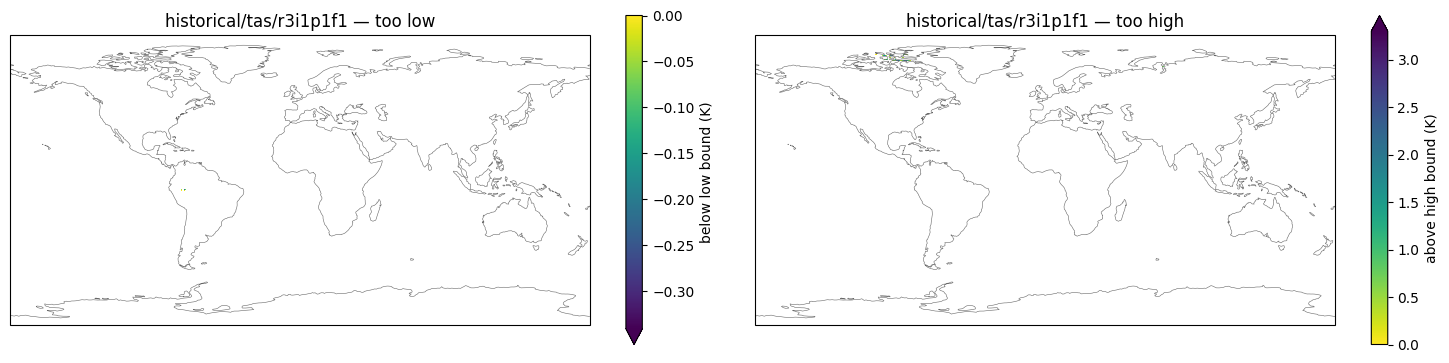

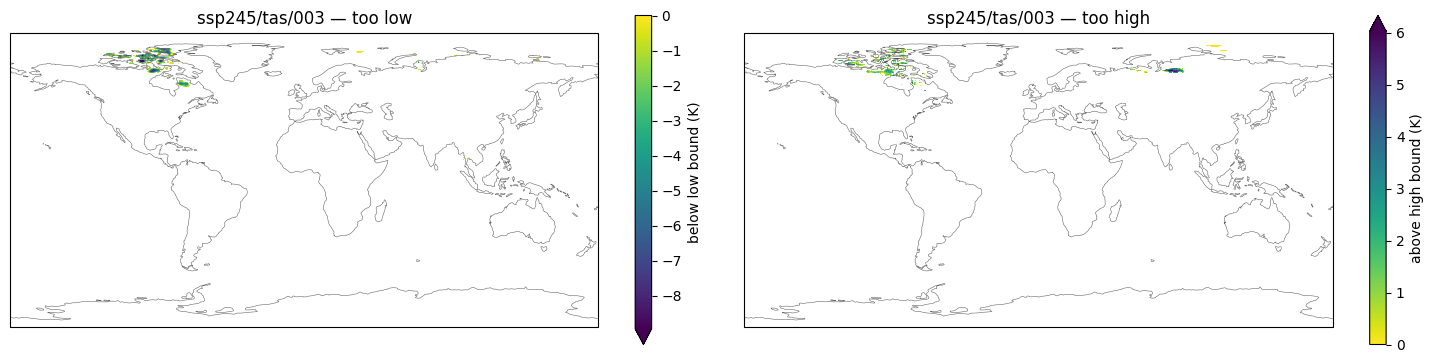

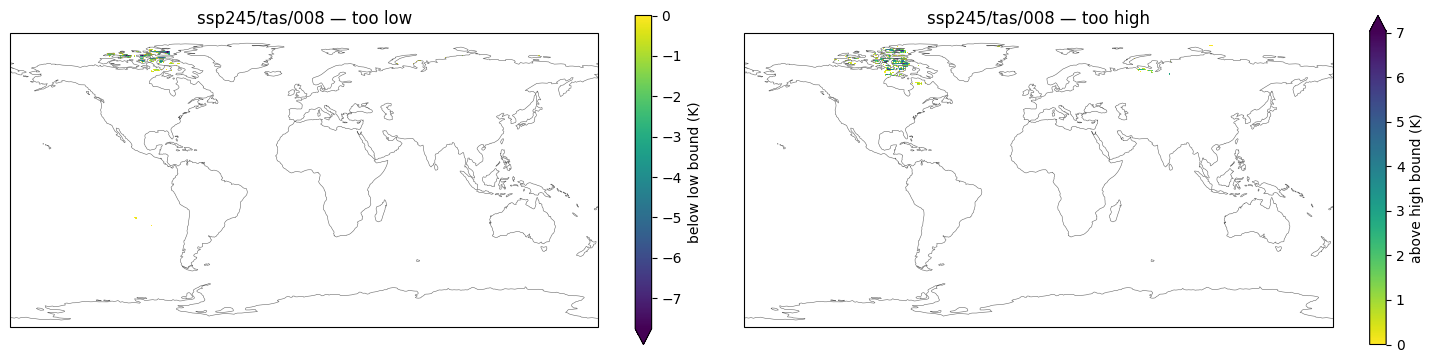

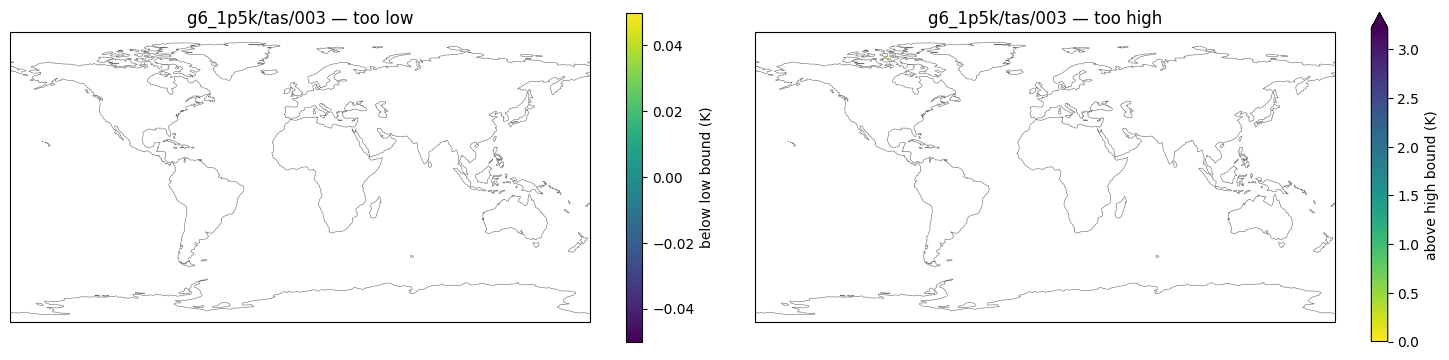

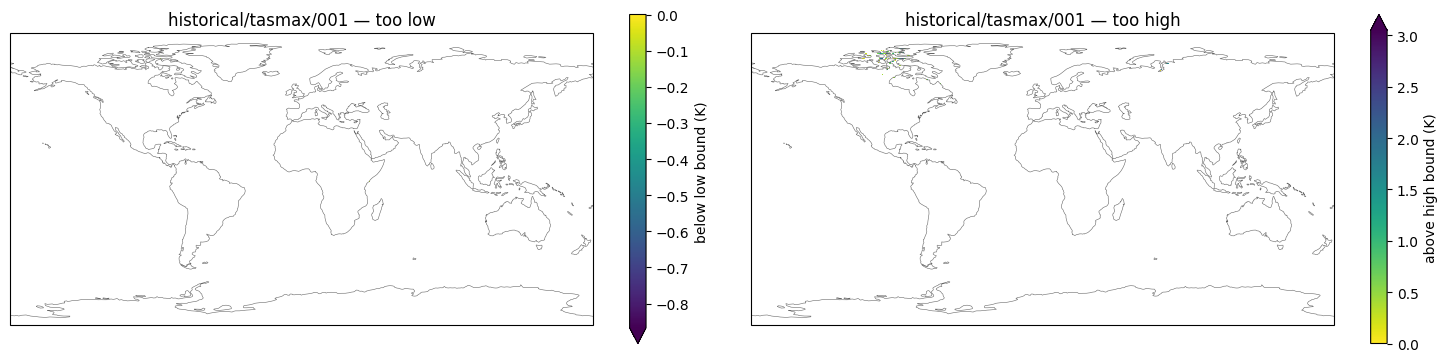

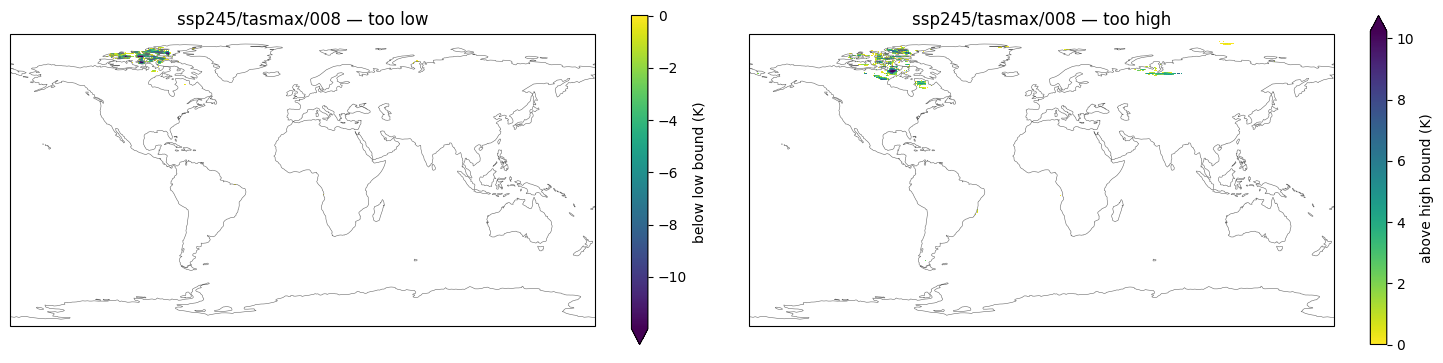

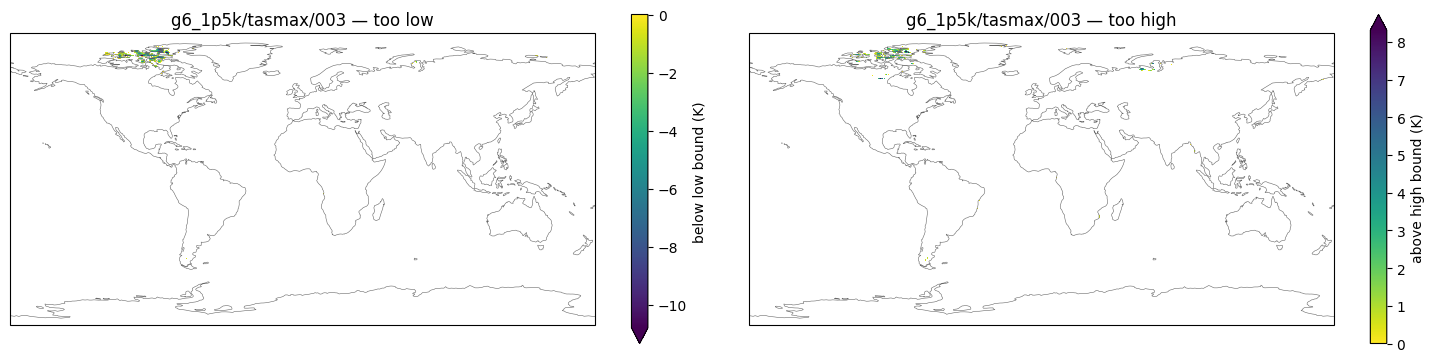

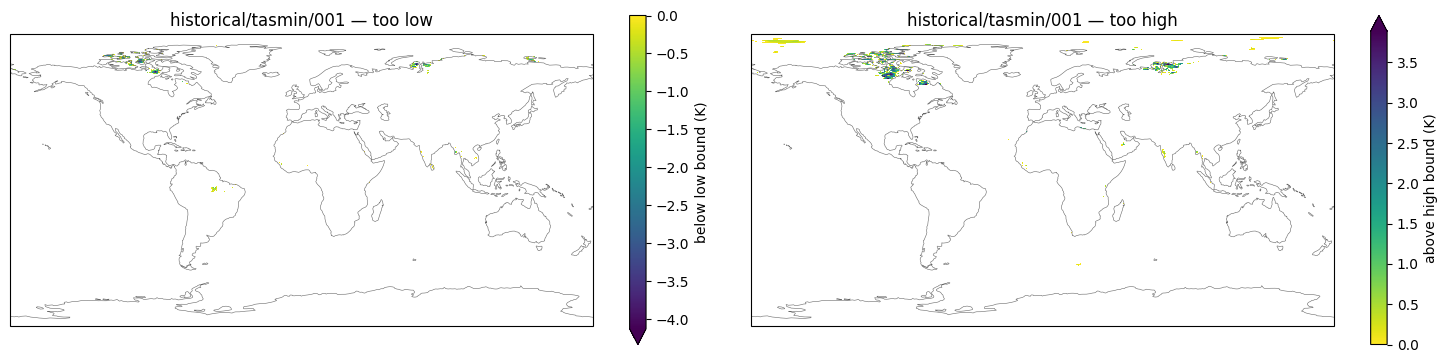

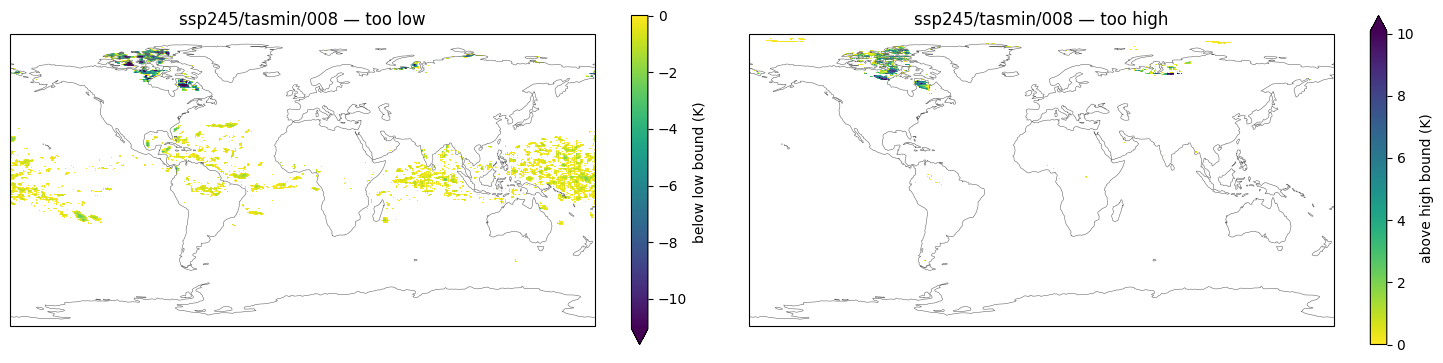

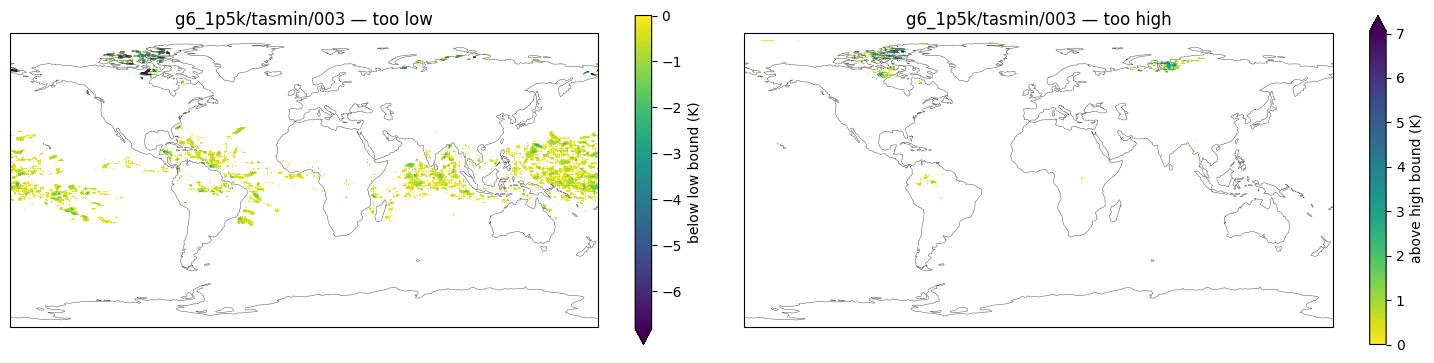

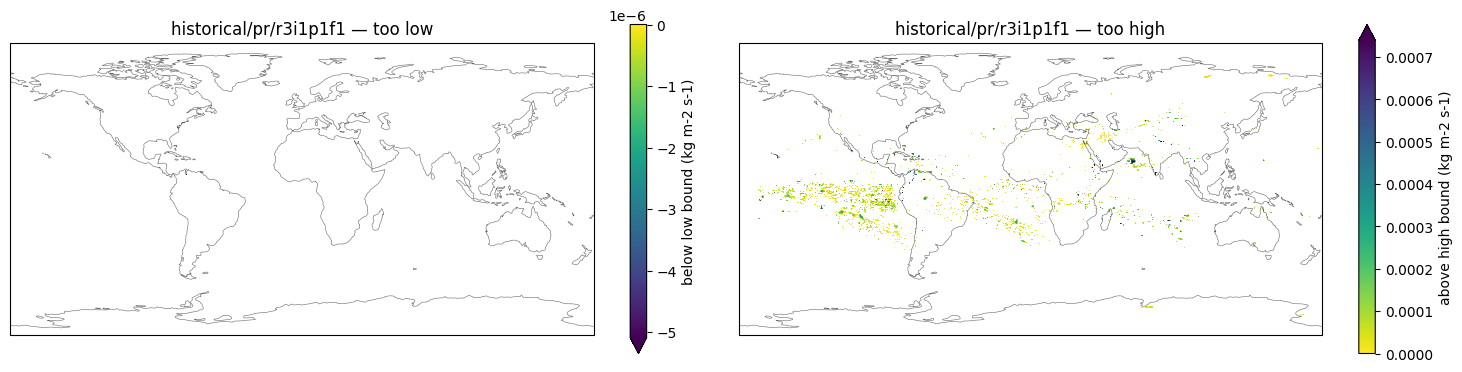

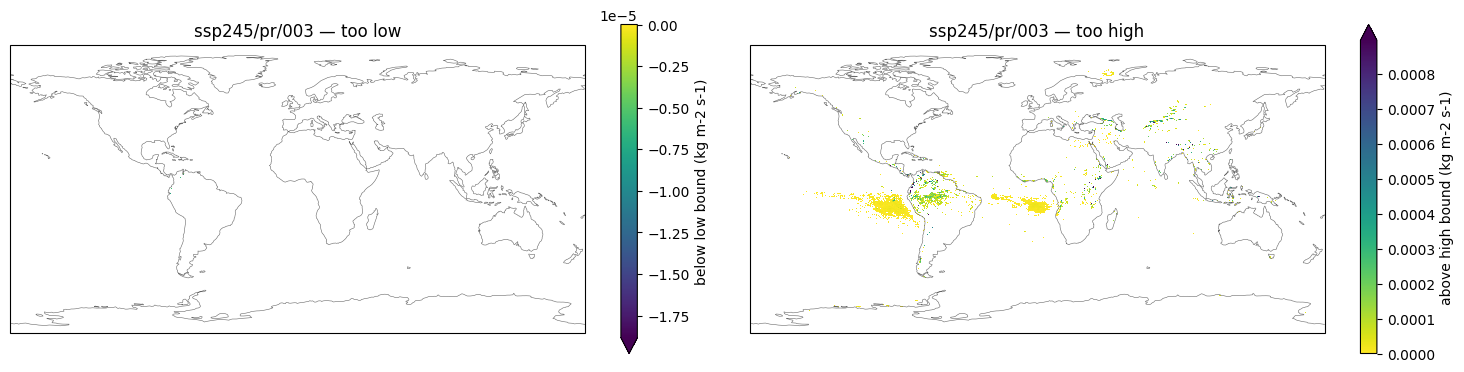

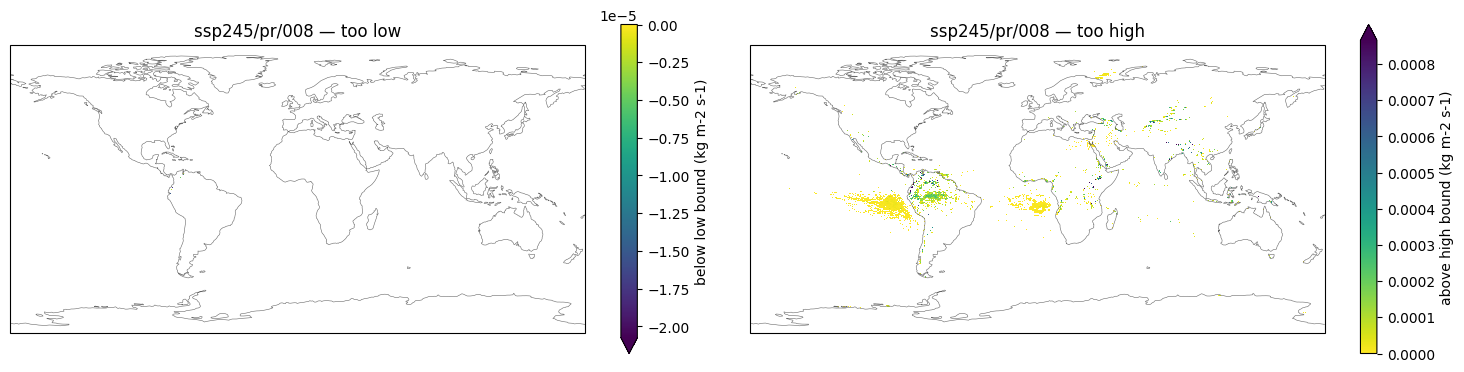

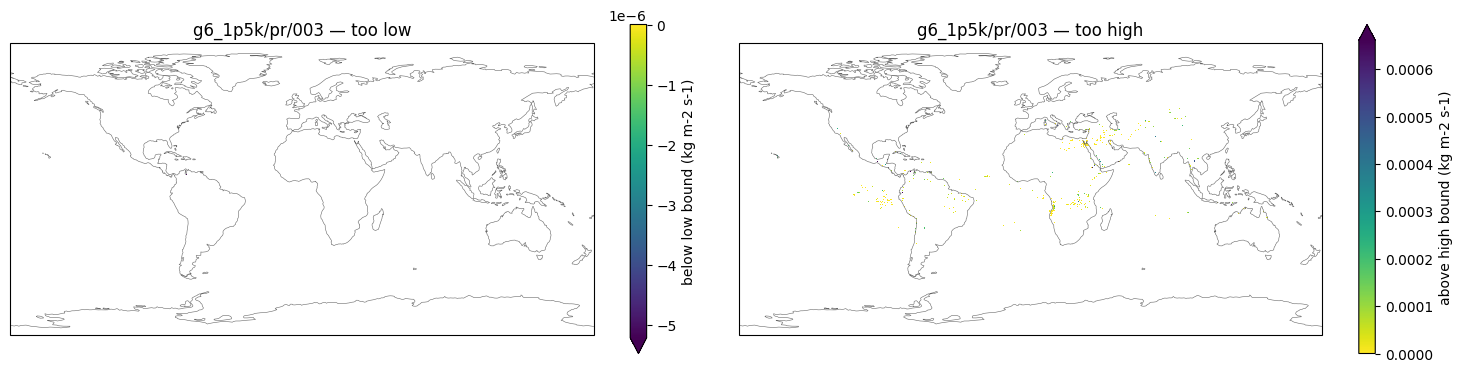

In [8]:
def _units_for(scenario: str, var: str, member: str) -> str:
    """Native units of a leaf, read from the store variable's attrs (falls back to '')."""
    return leaves[(scenario, var, member)].attrs.get("units", "")


def _robust_limit(da) -> float | None:
    """99th-percentile magnitude of the finite, non-zero exceedances, or None if none.

    A high quantile rather than the raw max keeps a single outlier cell from flattening
    the color scale; None lets matplotlib autoscale when nothing is flagged. Deriving the
    limit per leaf (not a fixed constant) is what lets kelvin temperatures and
    kg m-2 s-1 precipitation share the same plotting code.
    """
    vals = np.abs(da.values)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return None
    return float(np.quantile(vals, 0.99))


def plot_exceedance_maps(stats: dict) -> None:
    for (scenario, var, member), s in stats.items():
        units = _units_for(scenario, var, member)
        unit_suffix = f" ({units})" if units else ""
        lo_lim = _robust_limit(s.under.where(s.under < 0))
        hi_lim = _robust_limit(s.over.where(s.over > 0))

        fig = plt.figure(figsize=(15, 5))

        ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
        s.under.where(s.under < 0).plot(
            ax=ax1,
            transform=ccrs.PlateCarree(),
            vmin=None if lo_lim is None else -lo_lim,
            vmax=0,
            cbar_kwargs={"label": f"below low bound{unit_suffix}", "shrink": 0.7},
        )
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax1.set_title(f"{scenario}/{var}/{member} — too low")

        ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
        s.over.where(s.over > 0).plot(
            ax=ax2,
            transform=ccrs.PlateCarree(),
            cmap="viridis_r",
            vmin=0,
            vmax=hi_lim,
            cbar_kwargs={"label": f"above high bound{unit_suffix}", "shrink": 0.7},
        )
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax2.set_title(f"{scenario}/{var}/{member} — too high")

        plt.tight_layout()
        fig.savefig(f"{QAQC_DIR}map_out_of_range_{var}_{scenario}_{member}.png", dpi=100)
        plt.show()


plot_exceedance_maps(stats)

## Part 2 — single-point drill-down

A map tells you *where* a leaf leaves the envelope; to understand *why*, it helps to look at one grid
cell across the whole record. Below we pick one flagged leaf and one point and plot the downscaled
daily values against the plausible envelope and the underlying inputs (raw scenario GCM, raw
historical GCM, ERA5 observations, and the coarse debiased output). Change `drill_key` and the point
to inspect any cell; the defaults reproduce the example the original notebook zoomed in on.

In [9]:
# Default to a known flagged leaf if present, else the first flagged leaf, else the first leaf.
_preferred = ("ssp245", "tasmin", "008")
if _preferred in stats:
    drill_key = _preferred
else:
    _flagged = summary.index[~summary["pass"]]
    drill_key = tuple(_flagged[0]) if len(_flagged) else next(iter(stats))
drill_scenario, drill_var, drill_member = drill_key
ilat, ilon = 71.0, -109.0  # example point (store coordinate convention)
print(f"Drilling into {drill_scenario}/{drill_var}/{drill_member} at lat={ilat}, lon={ilon}")

# Rebuild the fine-grid bounds for this leaf, then select the single point (dask prunes the graph to
# the one column, so this stays cheap despite the global reindex expression).
low_obs, high_obs = obs_bounds_cached(drill_var)
_hist_member = historical_member(*drill_key)
raw_scenario = CESM[drill_scenario][drill_var].sel(ensemble_member=drill_member)
raw_historical = CESM["historical"][drill_var].sel(ensemble_member=_hist_member)
delta_low, delta_high = scenario_delta_doy(raw_scenario, raw_historical, window=WINDOW)
_regrid = {"lat": low_obs["lat"], "lon": low_obs["lon"], "method": "nearest"}

_pt = {"lat": ilat, "lon": ilon, "method": "nearest"}
pt_bound_high = (high_obs + delta_high.reindex(**_regrid)).sel(**_pt).compute()
pt_bound_low = (low_obs + delta_low.reindex(**_regrid)).sel(**_pt).compute()

pt_vals = leaves[drill_key].sel(**_pt).compute()
pt_obs = obs_fine(drill_var).sel(**_pt).compute()
pt_raw_scenario = raw_scenario.sel(**_pt).compute()
pt_raw_historical = raw_historical.sel(**_pt).compute()

_coarse_node = tree[f"debiased_coarse/{drill_scenario}"][f"{drill_var}/{drill_member}"]
pt_coarse = _coarse_node.dataset[drill_var].sel(**_pt).compute()

doy = pt_vals["time.dayofyear"]
pt_too_high = pt_vals > pt_bound_high.sel(dayofyear=doy)
pt_too_low = pt_vals < pt_bound_low.sel(dayofyear=doy)
_n_flagged = int((pt_too_high | pt_too_low).sum())
print(f"Flagged days at this point: {_n_flagged} of {pt_vals.sizes['time']}")

Drilling into ssp245/tasmin/008 at lat=71.0, lon=-109.0


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


Flagged days at this point: 2 of 20089


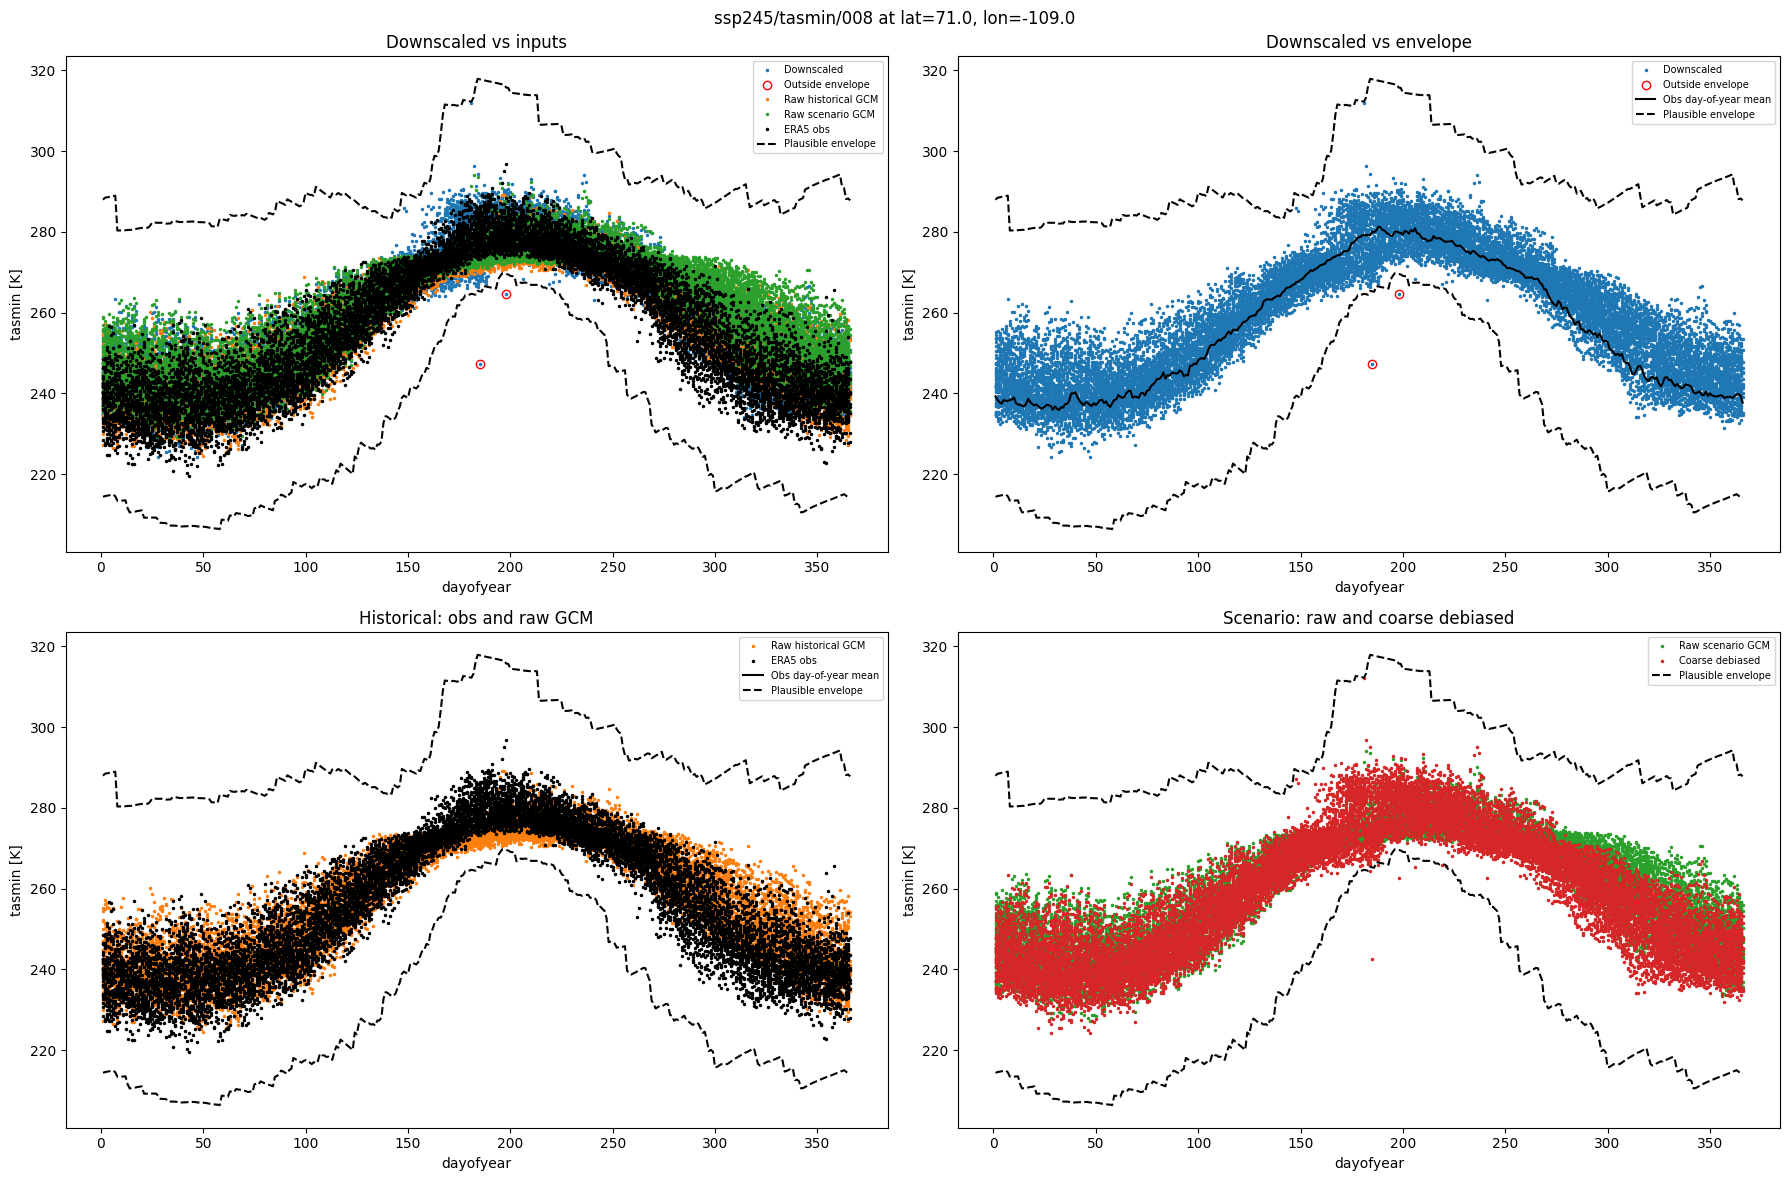

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
obs_doy_mean = pt_obs.groupby("time.dayofyear").mean()


def _series(ax, da, **kw):
    """Scatter a point time series against its day of year."""
    ax.plot(da["time.dayofyear"], da, ".", ms=3, **kw)


def _envelope(ax):
    """Overlay the plausible day-of-year envelope as dashed lines."""
    pt_bound_high.plot(ax=ax, color="black", ls="--", label="Plausible envelope")
    pt_bound_low.plot(ax=ax, color="black", ls="--")


def _outliers(ax):
    """Downscaled values, with red rings on the days that leave the envelope."""
    ax.plot(doy, pt_vals, ".", ms=3, label="Downscaled")
    ax.plot(doy, pt_vals.where(pt_too_high), "o", mfc="none", color="red", label="Outside envelope")
    ax.plot(doy, pt_vals.where(pt_too_low), "o", mfc="none", color="red")


# (0,0) Downscaled output vs envelope, with all inputs overlaid.
ax = axes[0, 0]
_outliers(ax)
_series(ax, pt_raw_historical, label="Raw historical GCM")
_series(ax, pt_raw_scenario, label="Raw scenario GCM")
_series(ax, pt_obs, color="black", label="ERA5 obs")
_envelope(ax)
ax.set_title("Downscaled vs inputs")
ax.legend(fontsize=7)

# (0,1) Downscaled output and envelope, with the observed day-of-year mean.
ax = axes[0, 1]
_outliers(ax)
ax.plot(obs_doy_mean["dayofyear"], obs_doy_mean, "-k", label="Obs day-of-year mean")
_envelope(ax)
ax.set_title("Downscaled vs envelope")
ax.legend(fontsize=7)

# (1,0) Historical: obs and raw GCM.
ax = axes[1, 0]
_series(ax, pt_raw_historical, color="C1", label="Raw historical GCM")
_series(ax, pt_obs, color="black", label="ERA5 obs")
ax.plot(obs_doy_mean["dayofyear"], obs_doy_mean, "-k", label="Obs day-of-year mean")
_envelope(ax)
ax.set_title("Historical: obs and raw GCM")
ax.legend(fontsize=7)

# (1,1) Scenario: raw GCM and coarse debiased.
ax = axes[1, 1]
_series(ax, pt_raw_scenario, color="C2", label="Raw scenario GCM")
_series(ax, pt_coarse, color="C3", label="Coarse debiased")
_envelope(ax)
ax.set_title("Scenario: raw and coarse debiased")
ax.legend(fontsize=7)

fig.suptitle(f"{drill_scenario}/{drill_var}/{drill_member} at lat={ilat}, lon={ilon}")
plt.tight_layout()
plt.show()

## Summary

Each leaf reports the fraction of the domain that ever leaves its per-day-of-year plausible envelope,
in each direction, together with the largest exceedance and a pass flag at the 2 % threshold. Because
the envelope is intentionally wide and day-of-year specific, a passing leaf is strong evidence that
the downscaling did not invent locally impossible values, while a flagged leaf points to specific
cells and days to inspect with the drill-down rather than to an automatic failure.

For the v0.11.1 store this covers 14 leaves — `tas`, `tasmax`, `tasmin`, and `pr` across the
`historical`, `ssp245`, and `g6_1p5k` groups. All four precipitation leaves pass: the flagged area
stays at or below about 1.6 % on the upper bound, and — as anticipated — the lower bound never fires
because precipitation cannot go negative. The only leaves that cross the 2 % threshold are two
`tasmin` leaves, `ssp245/tasmin/008` (~4.0 % too low) and `g6_1p5k/tasmin/003` (~4.5 % too low),
which are the leaves the single-point drill-down below zooms into.

The refactor keeps the original check's numbers but computes them differently: it discovers leaves
from the store instead of a hand-written list, builds every reduction lazily, computes the expensive
observed envelope once per variable, and evaluates that variable's leaves in one `dask.compute` on a
fixed, on-demand cluster. Batching by variable keeps each variable's leaves running in parallel while
bounding peak memory to one variable at a time, and the fixed on-demand pool removes the worker churn
— spot reclamation and adaptive downscaling — that made an all-at-once run lose its reduction
partials mid-compute.

In [11]:
cluster.shutdown()